# Imports and important variables

In [26]:
import re
import string
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from nltk.util import ngrams
from sklearn.manifold import TSNE
from wordcloud import WordCloud

nlp = spacy.load("en_core_web_sm")

from module.utils import getData


file_path = "data/NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
split_file_path_val = "data/dontpatronizeme/semeval-2022/practice splits/dev_semeval_parids-labels.csv"
split_file_path_train = "data/dontpatronizeme/semeval-2022/practice splits/train_semeval_parids-labels.csv"

splits = {
    "train": split_file_path_train,
    "val": split_file_path_val
}

train_data = getData(file_path, splits["train"])
val_data = getData(file_path, splits["val"])

In [37]:
def splitByLabel(dataset):
    patronizing = [d["text"] for d in dataset if d["label"] == 1]
    neutral = [d["text"] for d in dataset if d["label"] == 0]
    return patronizing, neutral


def basicClean(text):
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def tokenize(text):
    return text.lower().split()


def tokenizeNoStopwords(text):
    doc = nlp(text.lower())
    return [token.text for token in doc if not token.is_stop and not token.is_punct]


class StatisticalProfiler:
    def __init__(self, dataset):
        self.dataset = dataset
        self.texts = [d["text"] for d in dataset]
        self.labels = [d["label"] for d in dataset]

    def _computeTokenLengths(self):
        return [len(tokenize(t)) for t in self.texts]

    def _computeVocabularySize(self):
        all_tokens = []
        for t in self.texts:
            all_tokens.extend(tokenize(t))
        return len(set(all_tokens))

    def _classDistribution(self):
        counter = Counter(self.labels)
        total = len(self.labels)
        return {
            "patronizing (1)": counter[1],
            "neutral (0)": counter[0],
            "patronizing_pct": round(counter[1] / total * 100, 2),
            "neutral_pct": round(counter[0] / total * 100, 2),
            "imbalance_ratio": round(counter[0] / counter[1], 2) if counter[1] > 0 else None
        }

    def run(self):
        lengths = self._computeTokenLengths()
        vocab_size = self._computeVocabularySize()
        class_dist = self._classDistribution()

        print("\n[Statistical Profile]")
        print(f"\tTotal samples: {len(self.dataset)}")
        print(f"\tAvg tokens: {np.mean(lengths):.1f}")
        print(f"\tMin tokens: {np.min(lengths)}")
        print(f"\tMax tokens: {np.max(lengths)}")
        print(f"\tStd tokens: {np.std(lengths):.1f}")
        print(f"\tVocab size: {vocab_size}")

        print("\n[Class distribution]")
        print(f"\tPatronizing: {class_dist['patronizing (1)']} ({class_dist['patronizing_pct']}%)")
        print(f"\tNeutral: {class_dist['neutral (0)']} ({class_dist['neutral_pct']}%)")
        print(f"\tNeutral:Patronizing ratio: {class_dist['imbalance_ratio']}:1")

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].hist(lengths, bins=40)
        axes[0].set_title("Token Length Distribution")

        patronizing_lengths = [len(tokenize(d["text"])) for d in self.dataset if d["label"] == 1]
        neutral_lengths = [len(tokenize(d["text"])) for d in self.dataset if d["label"] == 0]
        axes[1].hist(patronizing_lengths, bins=30, alpha=0.6, label="Patronizing")
        axes[1].hist(neutral_lengths, bins=30, alpha=0.6, label="Neutral")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        labels_plot = list(class_dist.keys())[:2]
        values_plot = [class_dist["patronizing (1)"], class_dist["neutral (0)"]]

        fig, ax = plt.subplots(figsize=(4, 4))
        ax.pie(values_plot, labels=labels_plot, autopct="%1.1f%%", startangle=90)
        ax.set_title("Class Distribution")
        plt.show()

        return lengths, class_dist


class LexicalAnalyzer:
    def __init__(self, dataset):
        self.dataset = dataset
        self.patronizing, self.neutral = splitByLabel(dataset)

    def _getNgrams(self, texts, n, top_k=20):
        all_tokens = []
        for text in texts:
            tokens = tokenize(text)
            tokens = [t for t in tokens if t not in string.punctuation]
            all_tokens.extend(list(ngrams(tokens, n)))
        return Counter(all_tokens).most_common(top_k)

    def _stopwordDensity(self, texts):
        densities = []
        for text in texts:
            doc = nlp(text.lower())
            total = len([t for t in doc if not t.is_space])
            stop_count = len([t for t in doc if t.is_stop])
            densities.append(stop_count / total if total > 0 else 0)
        return np.mean(densities)

    def _plotNgrams(self, ngram_data, title, ax):
        phrases = [" ".join(g) for g, _ in ngram_data]
        counts = [c for _, c in ngram_data]
        ax.barh(phrases[::-1], counts[::-1])
        ax.set_title(title)

    def _generateWordCloud(self, texts, title, ax):
        combined = " ".join(texts)
        wc = WordCloud(width=600, height=400, background_color="white").generate(combined)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(title)

    def run(self):
        print("\n[Lexical Analysis]")
        pat_density = self._stopwordDensity(self.patronizing)
        neu_density = self._stopwordDensity(self.neutral)

        print(f"\tStopword density (patronizing): {pat_density:.3f}")
        print(f"\tStopword density (neutral): {neu_density:.3f}")

        fig, axes = plt.subplots(2, 2, figsize=(8, 6))
        pat_bigrams = self._getNgrams(self.patronizing, 2)
        neu_bigrams = self._getNgrams(self.neutral, 2)
        self._plotNgrams(pat_bigrams, "Top Bigrams — Patronizing", axes[0][0])
        self._plotNgrams(neu_bigrams, "Top Bigrams — Neutral", axes[0][1])
        self._generateWordCloud(self.patronizing, "Word Cloud — Patronizing", axes[1][0])
        self._generateWordCloud(self.neutral, "Word Cloud — Neutral", axes[1][1])
        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        pat_trigrams = self._getNgrams(self.patronizing, 3)
        neu_trigrams = self._getNgrams(self.neutral, 3)
        self._plotNgrams(pat_trigrams, "Top Trigrams — Patronizing", axes[0][0])
        self._plotNgrams(neu_trigrams, "Top Trigrams — Neutral", axes[0][1])
        pat_fourgrams = self._getNgrams(self.patronizing, 4)
        neu_fourgrams = self._getNgrams(self.neutral, 4)
        self._plotNgrams(pat_fourgrams, "Top 4-grams — Patronizing", axes[1][0])
        self._plotNgrams(neu_fourgrams, "Top 4-grams — Neutral", axes[1][1])
        plt.tight_layout()
        plt.show()

        return pat_bigrams, neu_bigrams, pat_trigrams, neu_trigrams, pat_fourgrams, neu_fourgrams


class SemanticAnalyzer:
    def __init__(self, dataset, sample_size=500):
        self.dataset = dataset
        self.sample_size = sample_size
        self.patronizing, self.neutral = splitByLabel(dataset)

    def _posDistribution(self, texts):
        pos_counts = Counter()
        for text in texts[:200]:
            doc = nlp(text)
            for token in doc:
                if not token.is_space:
                    pos_counts[token.pos_] += 1
        total = sum(pos_counts.values())
        return {k: round(v / total * 100, 2) for k, v in pos_counts.most_common(8)}

    def _nerDistribution(self, texts):
        ent_counts = Counter()
        for text in texts[:200]:
            doc = nlp(text)
            for ent in doc.ents:
                ent_counts[ent.label_] += 1
        return ent_counts.most_common(10)

    def run(self):
        print("\n[POS & Semantic Signals]")
        pos_pat = self._posDistribution(self.patronizing)
        pos_neu = self._posDistribution(self.neutral)

        print("\n[POS — Patronizing]")
        for k, v in pos_pat.items():
            print(f"\t{k}: {v}%")

        print("\n[POS — Neutral]")
        for k, v in pos_neu.items():
            print(f"\t{k}: {v}%")

        print("\n[Entities — Patronizing]")
        for ent, count in self._nerDistribution(self.patronizing):
            print(f"\t{ent}: {count}")

        print("\n[Entities — Neutral]")
        for ent, count in self._nerDistribution(self.neutral):
            print(f"\t{ent}: {count}")

        return pos_pat, pos_neu


class NoiseDetector:
    def __init__(self, dataset):
        self.dataset = dataset

    def _findDuplicates(self):
        texts = [d["text"] for d in self.dataset]
        seen = {}
        duplicates = []
        for i, text in enumerate(texts):
            if text in seen:
                duplicates.append((seen[text], i, text[:80]))
            else:
                seen[text] = i
        return duplicates

    def _findSpecialCharArtifacts(self):
        patterns = {
            "html_tags": re.compile(r"<[^>]+>"),
            "html_entities": re.compile(r"&\w+;"),
            "urls": re.compile(r"https?://\S+"),
            "non_ascii": re.compile(r"[^\x00-\x7F]+"),
        }
        flagged = {k: [] for k in patterns}
        for d in self.dataset:
            for name, pattern in patterns.items():
                if pattern.search(d["text"]):
                    flagged[name].append(d["id"])
        return flagged

    def _findOutliers(self, lengths, threshold_low=5):
        threshold_high = np.percentile(lengths, 99)
        outliers_low = [i for i, l in enumerate(lengths) if l < threshold_low]
        outliers_high = [i for i, l in enumerate(lengths) if l > threshold_high]
        return outliers_low, outliers_high, threshold_high

    def run(self, lengths):
        print("\n[Noise Check]")
        duplicates = self._findDuplicates()
        print(f"\tDuplicates: {len(duplicates)}")

        artifacts = self._findSpecialCharArtifacts()
        print("\nArtifacts:")
        for k, v in artifacts.items():
            print(f"\t{k}: {len(v)}")

        outliers_low, outliers_high, high_thresh = self._findOutliers(lengths)
        print("\nOutliers:")
        print(f"\tToo short (<5 tokens): {len(outliers_low)}")
        print(f"\tToo long (> {int(high_thresh)} tokens): {len(outliers_high)}")
        print(f"\nSuggested max_length: {int(np.percentile(lengths, 95))}")

        return artifacts, outliers_low, outliers_high

def runFullEda(dataset):
    print("\n[Full EDA]")
    print("Task: Patronizing Language Detection")

    profiler = StatisticalProfiler(dataset)
    lengths, class_dist = profiler.run()

    lexical = LexicalAnalyzer(dataset)
    lexical.run()

    semantic = SemanticAnalyzer(dataset)
    semantic.run()

    noise = NoiseDetector(dataset)
    noise.run(lengths)

    imbalance = class_dist.get("imbalance_ratio")
    if imbalance and imbalance > 3:
        print(f"\nImbalance detected: {imbalance}:1")

    print("\nDone.")


[Full EDA]
Task: Patronizing Language Detection

[Statistical Profile]
	Total samples: 8375
	Avg tokens: 48.7
	Min tokens: 1
	Max tokens: 909
	Std tokens: 29.7
	Vocab size: 29966

[Class distribution]
	Patronizing: 794 (9.48%)
	Neutral: 7581 (90.52%)
	Neutral:Patronizing ratio: 9.55:1


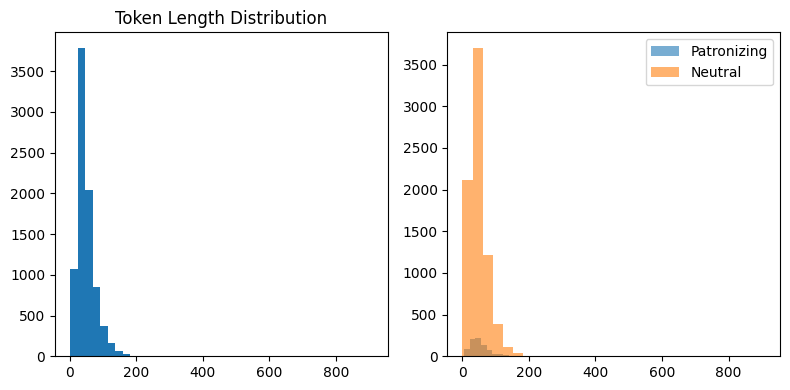

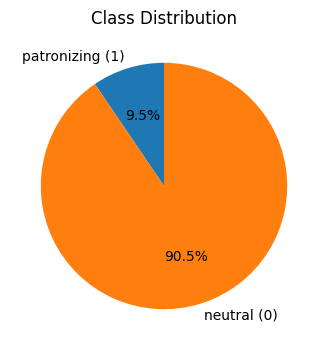


[Lexical Analysis]
	Stopword density (patronizing): 0.429
	Stopword density (neutral): 0.402


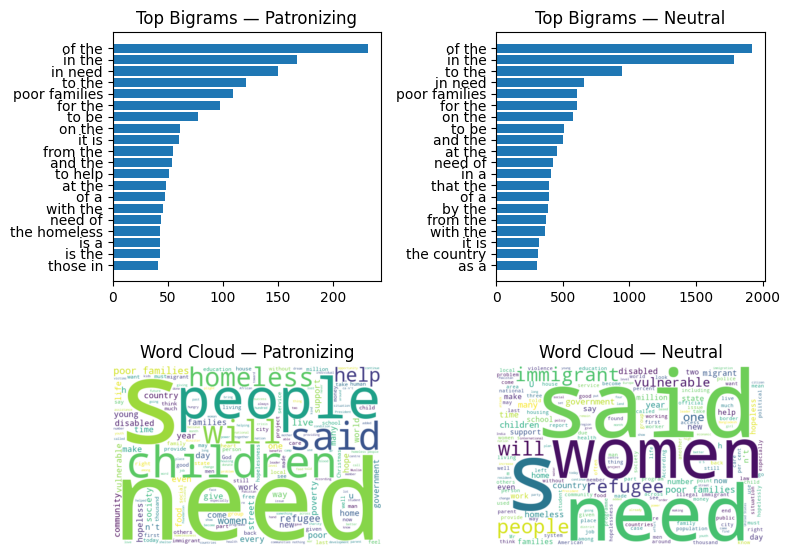

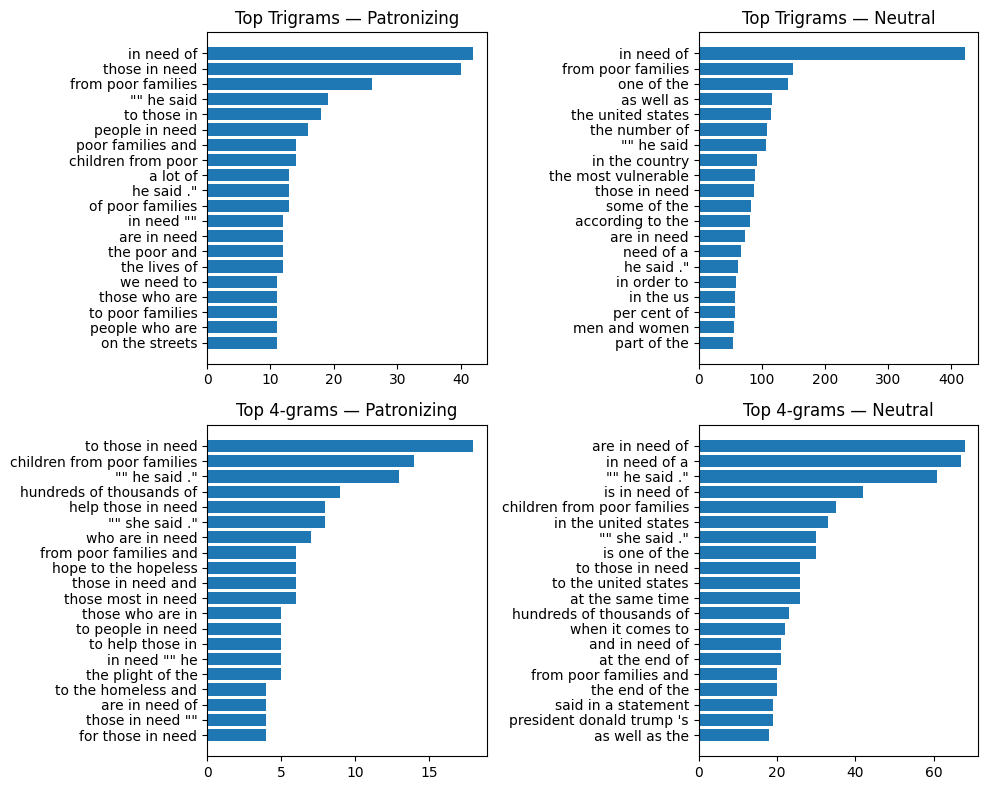


[POS & Semantic Signals]

[POS — Patronizing]
	NOUN: 18.41%
	PUNCT: 13.97%
	VERB: 10.89%
	ADP: 10.76%
	DET: 7.53%
	ADJ: 7.17%
	PRON: 7.09%
	PROPN: 6.64%

[POS — Neutral]
	NOUN: 18.67%
	PUNCT: 13.13%
	ADP: 11.39%
	VERB: 10.62%
	PROPN: 7.84%
	DET: 7.67%
	ADJ: 7.52%
	PRON: 5.61%

[Entities — Patronizing]
	GPE: 110
	ORG: 100
	PERSON: 95
	DATE: 69
	CARDINAL: 38
	NORP: 37
	LOC: 15
	ORDINAL: 12
	WORK_OF_ART: 8
	MONEY: 5

[Entities — Neutral]
	ORG: 134
	DATE: 122
	GPE: 122
	PERSON: 109
	CARDINAL: 85
	NORP: 76
	LOC: 18
	ORDINAL: 16
	WORK_OF_ART: 11
	TIME: 10

[Noise Check]
	Duplicates: 0

Artifacts:
	html_tags: 316
	html_entities: 65
	urls: 0
	non_ascii: 0

Outliers:
	Too short (<5 tokens): 11
	Too long (> 142 tokens): 79

Suggested max_length: 102

Imbalance detected: 9.55:1

Done.


In [38]:
runFullEda(train_data)